# Two-Stage Pre-Execution Malware Detection Demo

> Reproducing the core ideas of **two-stage pre-execution detection** from the
> Kaspersky whitepaper *Machine Learning Methods for Malware Detection*.

## The whitepaper's scheme in a nutshell

Kaspersky's products run a **two-stage** static analysis before a file is ever executed:

**Stage 1 — Pre-detect (cheap screening)**
- Extract only **lightweight features** (byte statistics, basic file structure) at
  near-zero cost;
- Compute a **similarity hash** over them (a supervised variant of locality-sensitive
  hashing);
- Files with the same hash value fall into the same **hash bucket**:
  - **pure malware bucket** (simple region) → flag as malware, scan ends;
  - **pure benign bucket** (simple region) → release, scan ends;
  - **mixed bucket** (hard region) → undecidable, pass to the second stage.

**Stage 2 — Detect (precise analysis)**
- Only files that landed in a hard region get **heavy features** extracted
  (strings, import tables, section info, ...);
- A **decision-tree ensemble** (region-specific models in the paper) makes the
  final call.

Two design goals drive everything:
1. **Performance**: most files are resolved in Stage 1 without paying for heavy
   feature extraction;
2. **Low false positives**: the Stage 2 classifier is trained on *hard-region malware
   plus ALL benign samples*, so the malware-skewed input distribution is "calibrated"
   by a large clean set first.

## What this demo builds

| Whitepaper concept | Demo implementation |
|---|---|
| Data | Public **EMBER 2018** dataset (static features of 1.1M PE files, temporal train/test split) |
| Lightweight features | Byte histogram + byte-entropy histogram + basic structure (522 dims) |
| Heavy features | Lightweight + strings / PE header / sections / imports & exports (1248 dims) |
| Stage 1 similarity hash mapping | **Supervised leaf-path hashing** (concatenated leaf ids of a shallow random forest) + bucket purity rules |
| Stage 2 tree ensemble | **XGBoost** (hard-region-biased training set) |
| Evaluation | Two-stage funnel visualization, detection/false-positive rates, error case attribution |


## 1. The dataset: EMBER 2018

[EMBER](https://github.com/elastic/ember) (Endgame Malware BEnchmark for Research)
provides **pre-extracted static features** (JSON) of 1.1 million PE files — it does
**not** contain the binaries themselves, so we can experiment safely without storing
real malware on this machine.

- **train**: 900K files (300K malware / 300K benign / 300K unlabeled), first seen ≤ 2018-10
- **test**: 200K files (100K malware / 100K benign), first seen 2018-11 ~ 2018-12
  (**strictly later than the training set** — simulating real deployment)
- Each record contains: `histogram` (byte histogram), `byteentropy`, `strings`,
  `general`, `header`, `section`, `imports`, `exports`, `datadirectories`, plus
  `sha256`/`md5`/`label`/`avclass` (AV family label)

To keep the demo runtime manageable we **randomly sample**: 80K malware + 80K benign
for training, 10K + 10K for testing. (The density of similarity-hash buckets depends
on the size of the training corpus — the more samples, the stronger Stage 1 becomes.)
Sampling uses random byte seeks so we never load the multi-GB JSONL files into memory.


In [1]:
import json, os, math, time, pickle
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.feature_extraction import FeatureHasher
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')  # silence GPU/CPU data transfer notes

# Train XGBoost with CUDA when an NVIDIA GPU is available (several times faster on an RTX 5070)
XGB_DEVICE = 'cuda' if os.system('nvidia-smi >/dev/null 2>&1') == 0 else 'cpu'

DATA_DIR = 'data/ember2018'
CACHE_DIR = 'data/cache'
os.makedirs(CACHE_DIR, exist_ok=True)

SEED = 42
N_TRAIN_PER_CLASS = 80000   # training samples per class (bucket density depends on corpus size)
N_TEST_PER_CLASS  = 10000   # test samples per class
TRAIN_FILES = [f'{DATA_DIR}/train_features_{i}.jsonl' for i in (1, 3, 5)]
TEST_FILES  = [f'{DATA_DIR}/test_features.jsonl']

# ---- unified chart style ----
PAL = dict(surface='#fcfcfb', ink='#0b0b0b', ink2='#52514e', muted='#898781',
           grid='#e1e0d9', axis='#c3c2b7',
           blue='#2a78d6', orange='#eb6834', aqua='#1baf7a', yellow='#eda100',
           mal='#e34948',            # malware / pure malware bucket
           ben='#2a78d6',            # benign / pure benign bucket
           hard='#eda100',           # hard region
           unseen='#898781',         # bucket never seen in training
           funnel=['#86b6ef', '#2a78d6', '#104281'])
mpl.rcParams.update({
    'figure.facecolor': PAL['surface'], 'axes.facecolor': PAL['surface'],
    'savefig.facecolor': PAL['surface'],
    'text.color': PAL['ink'], 'axes.labelcolor': PAL['ink2'],
    'xtick.color': PAL['ink2'], 'ytick.color': PAL['ink2'],
    'axes.edgecolor': PAL['axis'], 'grid.color': PAL['grid'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'figure.dpi': 110})

def style_ax(ax, ygrid=True, xgrid=False):
    if ygrid: ax.grid(axis='y', lw=0.8)
    if xgrid: ax.grid(axis='x', lw=0.8)
    ax.set_axisbelow(True)

print('xgboost', xgb.__version__, '| numpy', np.__version__, '| pandas', pd.__version__, '| XGB device:', XGB_DEVICE)

xgboost 3.4.1 | numpy 2.5.2 | pandas 3.0.5 | XGB device: cuda


## 2. Feature engineering: lightweight vs heavy features

The whitepaper's central engineering assumption is that **features come at different
costs**.

- **Lightweight features** (used by Stage 1): "*calculated quickly, like statistics
  derived from file byte content ... or directly retrieved from the structure of the
  executable*". We take:
  - `histogram`: 256-dim byte histogram (normalized)
  - `byteentropy`: 256-dim joint byte/entropy histogram (normalized)
  - `general`: 10 structural facts — file size, import/export counts, presence of a
    digital signature / debug info, etc.
  - **522 dims** total
- **Heavy features** (used by Stage 2, a superset of the lightweight ones): additionally
  - `strings`: printable-string statistics (count, average length, URL/path/registry
    counts, character distribution — 104 dims)
  - `header`: numeric PE header fields + COFF/Optional Header enums (feature-hashed)
  - `section`: section count/property stats + (section name, size/entropy) pairs (feature-hashed)
  - `imports` / `exports`: imported libraries, `lib:function` pairs, exported functions (feature-hashed)
  - `datadirectories`: sizes/virtual addresses of the 15 data directories
  - **1248 dims** total

> In a real product "heavy" means **extraction cost** (parsing the PE, disassembling,
> pulling strings). EMBER has already extracted everything for us, so in this demo
> "light vs heavy" becomes a **feature-subset split** — but the two-stage logic is
> identical: Stage 1 may only look at lightweight features, and only files that reach
> Stage 2 "pay" for the heavy ones.

String-valued features (import names, section names, ...) are mapped to fixed
dimensions with **feature hashing** (same approach as EMBER's official vectorizer).

In [2]:
def norm_hist(a):
    a = np.asarray(a, dtype=np.float64)
    return a / max(a.sum(), 1.0)

DD_NAMES = ['EXPORT_TABLE','IMPORT_TABLE','RESOURCE_TABLE','EXCEPTION_TABLE',
            'CERTIFICATE_TABLE','BASE_RELOCATION_TABLE','DEBUG','ARCHITECTURE',
            'GLOBAL_PTR','TLS_TABLE','LOAD_CONFIG_TABLE','BOUND_IMPORT','IAT',
            'DELAY_IMPORT_DESCRIPTOR','CLR_RUNTIME_HEADER']

def extract(o):
    """Extract feature material from one EMBER JSON record.
    Returns (lightweight vec 522, heavy numeric part 150, string tokens to hash, metadata)."""
    # ---------- lightweight: byte statistics + basic structure ----------
    hist = norm_hist(o['histogram'])       # 256, byte histogram
    be   = norm_hist(o['byteentropy'])     # 256, byte-entropy histogram
    g = o['general']
    gen = np.array([math.log1p(g['size']), math.log1p(g['vsize']),
                    g['has_debug'], math.log1p(g['exports']), math.log1p(g['imports']),
                    g['has_relocations'], g['has_resources'], g['has_signature'],
                    g['has_tls'], math.log1p(g['symbols'])])
    light = np.concatenate([hist, be, gen]).astype(np.float32)          # 522 dims

    # ---------- heavy (numeric part) ----------
    s = o['strings']
    strings_vec = np.concatenate([
        [math.log1p(s['numstrings']), s['avlength'], math.log1p(s['printables']),
         s['entropy'], math.log1p(s['paths']), math.log1p(s['urls']),
         math.log1p(s['registry']), math.log1p(s['MZ'])],
        norm_hist(s['printabledist'])])                                  # 104 dims

    h    = o.get('header') or {}
    coff = h.get('coff') or {}
    opt  = h.get('optional') or {}
    header_num = np.array(
        [opt.get(k, 0) for k in (
            'major_image_version','minor_image_version','major_linker_version',
            'minor_linker_version','major_operating_system_version',
            'minor_operating_system_version','major_subsystem_version',
            'minor_subsystem_version')] +
        [math.log1p(opt.get('sizeof_code', 0)), math.log1p(opt.get('sizeof_headers', 0)),
         math.log1p(opt.get('sizeof_heap_commit', 0))])                  # 11 dims

    sec = o.get('section') or {}
    sections = sec.get('sections') or []
    sec_num = np.array([len(sections),
                        sum(1 for x in sections if x.get('size', 0) == 0),
                        sum(1 for x in sections if not x.get('name')),
                        sum(1 for x in sections if 'MEM_EXECUTE' in (x.get('props') or [])),
                        sum(1 for x in sections if 'MEM_WRITE' in (x.get('props') or []))])  # 5 dims

    dd = {d.get('name'): d for d in (o.get('datadirectories') or [])}
    dd_vec = np.array([v for n in DD_NAMES for v in
                       (math.log1p(dd.get(n, {}).get('size', 0)),
                        math.log1p(dd.get(n, {}).get('virtual_address', 0)))])  # 30 dims

    heavy_num = np.concatenate([strings_vec, header_num, sec_num, dd_vec]).astype(np.float32)

    # ---------- heavy (string tokens, feature-hashed later) ----------
    entry = sec.get('entry', '')
    imports = o.get('imports') or {}
    tokens = dict(
        header=[f"machine:{coff.get('machine','')}", f"subsystem:{opt.get('subsystem','')}",
                f"magic:{opt.get('magic','')}"]
               + [f"coff:{c}" for c in (coff.get('characteristics') or [])]
               + [f"dll:{c}" for c in (opt.get('dll_characteristics') or [])],
        entry=[f"entry:{entry}"] + [f"entryprop:{p}" for x in sections
                                    if x.get('name') == entry for p in (x.get('props') or [])],
        sec_size=[(x.get('name') or '?', float(x.get('size', 0))) for x in sections],
        sec_ent =[(x.get('name') or '?', float(x.get('entropy', 0))) for x in sections],
        libs=[l.lower() for l in imports],
        funcs=[f"{l.lower()}:{fn}" for l, fl in imports.items() for fn in fl],
        exports=list(o.get('exports') or []),
    )
    meta = dict(sha256=o['sha256'], md5=o['md5'], label=o['label'],
                avclass=o.get('avclass', ''), appeared=o.get('appeared', ''))
    return light, heavy_num, tokens, meta

print('feature schema per record:')
print('  lightweight 522 = histogram 256 + byteentropy 256 + general 10   (Stage 1 may only see these)')
print('  heavy numeric 150 = strings 104 + header 11 + section 5 + datadirectories 30')
print('  + 7 string-token groups (imports, section names, ...) -> feature-hashed to 576 dims in the next cells')
print('  heavy total = 522 + 150 + 576 = 1248 dims (only extracted for files that reach Stage 2)')

feature schema per record:
  lightweight 522 = histogram 256 + byteentropy 256 + general 10   (Stage 1 may only see these)
  heavy numeric 150 = strings 104 + header 11 + section 5 + datadirectories 30
  + 7 string-token groups (imports, section names, ...) -> feature-hashed to 576 dims in the next cells
  heavy total = 522 + 150 + 576 = 1248 dims (only extracted for files that reach Stage 2)


In [3]:
def sample_records(paths, quota, seed):
    """Sample huge JSONL files via random seeks: jump to a random byte offset,
    discard the partial line, parse the next full line.
    quota: {label: samples needed}; other labels (e.g. unlabeled -1) are skipped."""
    rng = np.random.default_rng(seed)
    sizes = np.array([os.path.getsize(p) for p in paths], dtype=np.float64)
    probs = sizes / sizes.sum()
    remaining = dict(quota)
    seen = set()
    fhs = [open(p, 'rb') for p in paths]
    lights, heavies, tokens, metas = [], [], [], []
    attempts, max_attempts = 0, 400 * sum(quota.values())
    while any(v > 0 for v in remaining.values()) and attempts < max_attempts:
        attempts += 1
        i = rng.choice(len(paths), p=probs)
        f = fhs[i]
        f.seek(int(rng.integers(0, sizes[i])))
        f.readline()                       # drop the (possibly partial) half line
        line = f.readline()
        if not line:
            continue
        o = json.loads(line)
        if remaining.get(o['label'], 0) <= 0 or o['sha256'] in seen:
            continue
        seen.add(o['sha256'])
        remaining[o['label']] -= 1
        l, hn, tk, m = extract(o)
        lights.append(l); heavies.append(hn); tokens.append(tk); metas.append(m)
    for f in fhs:
        f.close()
    order = np.random.default_rng(seed + 7).permutation(len(metas))
    return dict(Xl=np.stack(lights)[order],
                Hnum=np.stack(heavies)[order],
                tokens=[tokens[j] for j in order],
                meta=pd.DataFrame([metas[j] for j in order]))

def load_or_build(split, paths, quota, seed):
    cache = f"{CACHE_DIR}/{split}_{sum(quota.values())}.pkl"
    if os.path.exists(cache):
        with open(cache, 'rb') as fp:
            d = pickle.load(fp)
        print(f"[{split}] loaded from cache {cache}: {len(d['meta'])} records")
        return d
    t0 = time.time()
    d = sample_records(paths, quota, seed)
    with open(cache, 'wb') as fp:
        pickle.dump(d, fp, protocol=4)
    print(f"[{split}] sampled {len(d['meta'])} records in {time.time()-t0:.0f}s -> cached")
    return d

train = load_or_build('train', TRAIN_FILES, {0: N_TRAIN_PER_CLASS, 1: N_TRAIN_PER_CLASS}, SEED)
test  = load_or_build('test',  TEST_FILES,  {0: N_TEST_PER_CLASS,  1: N_TEST_PER_CLASS},  SEED + 1)
y_train = train['meta']['label'].to_numpy()
y_test  = test['meta']['label'].to_numpy()
print('train label counts:', dict(Counter(y_train)), '| test:', dict(Counter(y_test)))

[train] sampled 160000 records in 112s -> cached


[test] sampled 20000 records in 10s -> cached
train label counts: {np.int64(1): 80000, np.int64(0): 80000} | test: {np.int64(0): 10000, np.int64(1): 10000}


In [4]:
HASH_SPECS = [('header', 64, 'string'), ('entry', 32, 'string'),
              ('sec_size', 64, 'pair'), ('sec_ent', 64, 'pair'),
              ('libs', 64, 'string'), ('funcs', 256, 'string'), ('exports', 32, 'string')]

def hash_tokens(tokens_list):
    """Feature-hash the string tokens into fixed-width matrices (576 dims total)."""
    parts = []
    for key, n, inp in HASH_SPECS:
        fh = FeatureHasher(n_features=n, input_type=inp)
        parts.append(fh.transform([t[key] for t in tokens_list]).toarray().astype(np.float32))
    return np.hstack(parts)

Xl_train = train['Xl']
Xl_test  = test['Xl']
Xh_train = np.hstack([Xl_train, train['Hnum'], hash_tokens(train['tokens'])])
Xh_test  = np.hstack([Xl_test,  test['Hnum'],  hash_tokens(test['tokens'])])
print(f'lightweight features: {Xl_train.shape[1]} dims | heavy features: {Xh_train.shape[1]} dims')
print(f'train: {Xh_train.shape}, test: {Xh_test.shape}')

lightweight features: 522 dims | heavy features: 1248 dims
train: (160000, 1248), test: (20000, 1248)


## 3. Stage 1: supervised similarity hashing + hash buckets

The whitepaper is explicit that the pre-detect similarity hash is **trained**
(supervised similarity hashing):

> "*During training, the algorithm fits parameters of hash mapping h(X) to maximize the
> number of pairs from the training set, for which h(X1) and h(X2) are identical for
> similar objects and different otherwise.*"

Why not plain unsupervised LSH (SimHash / bucketing raw TLSH)? While building this
demo we first tried random-hyperplane SimHash: **the bucket boundaries have nothing to
do with the malware/benign boundary**, and samples from a later time period easily
cross a random cutting plane — on the test set it resolved fewer than 10% of files,
with an error rate of several percent. That is exactly why the whitepaper makes the
hash mapping supervised.

The demo uses a simple supervised implementation that stays close to the paper's
"segmentation of object-space" illustration — **decision-tree leaf-path hashing**:

1. Train $T$ shallow decision trees (a random forest) on the **lightweight features**
   (labels participate in training → "supervised");
2. Each tree partitions the object space into leaf regions — a **learned segmentation**
   whose cuts all land on features that are informative for malware-vs-benign;
3. A file's **similarity hash value** = the tuple of leaf ids it reaches across the
   $T$ trees, $(leaf_1,\dots,leaf_T)$. Only files that walk into the same leaf in
   **every** tree share a bucket — similar variants naturally cluster together;
4. Use the **training set** to tally each bucket's malware/benign composition and
   classify buckets into three kinds:

| Bucket type | Condition (training-set tally) | Action |
|---|---|---|
| **pure malware bucket** (simple region) | only malware, and ≥ `MIN_SUPPORT` samples | flag as malware |
| **pure benign bucket** (simple region) | only benign, and ≥ `MIN_SUPPORT` samples | release |
| **hard region** | mixed, or too few samples | send to Stage 2 |

At test time a file that lands in a bucket **never seen during training** (unseen)
carries no prior information and also goes to Stage 2.

`MIN_SUPPORT` embodies the whitepaper's anti-false-positive stance: with insufficient
evidence, prefer spending compute over making a rash verdict.

**The hyperparameter (tree depth) trade-off**: shallow trees → big mixed leaves
(everything becomes a hard region); deep trees → pure but fragmented buckets (test
files fall into unseen buckets). We sweep it on a **validation set** below.

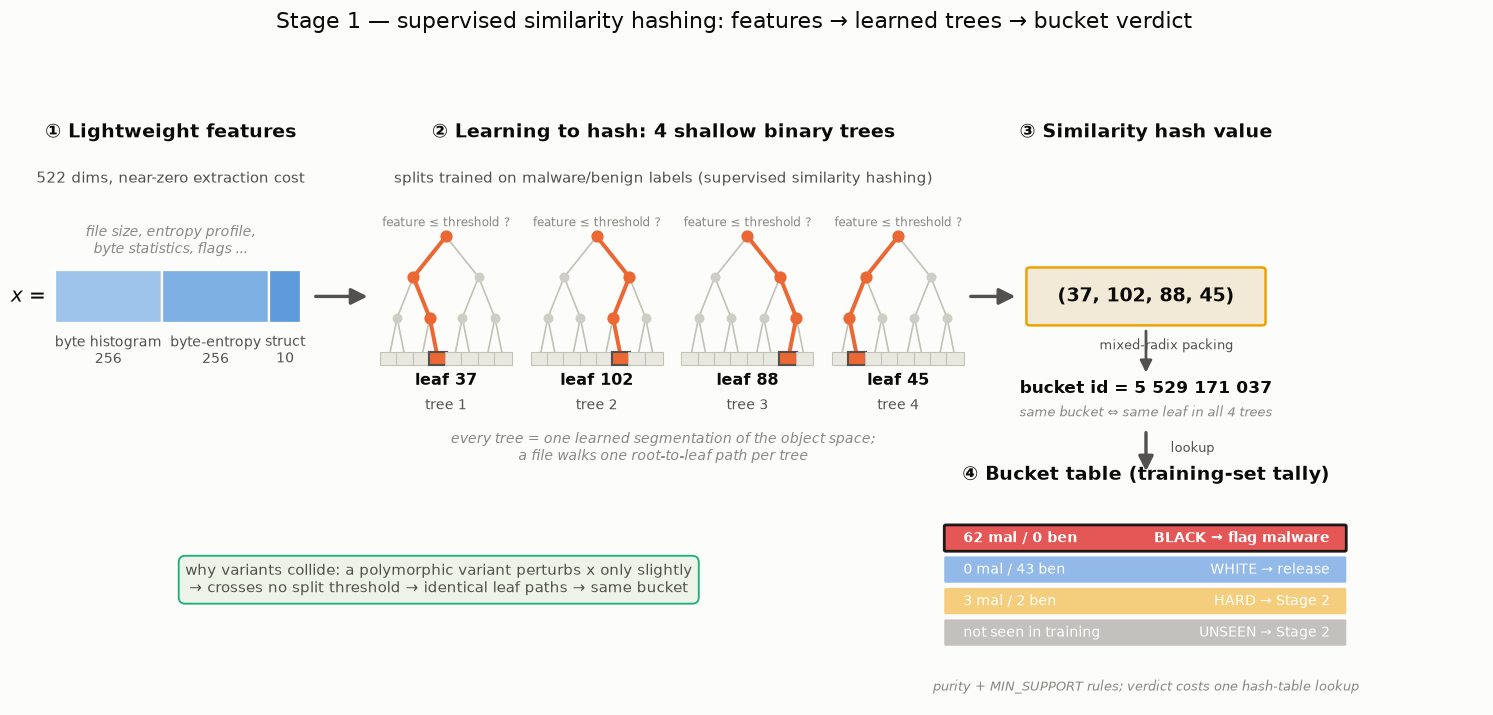

In [6]:
# ---- Stage 1 at a glance: lightweight features -> learned trees -> bucket verdict ----
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

fig, ax = plt.subplots(figsize=(17, 7.2))
ax.set_xlim(0, 100); ax.set_ylim(-4, 56); ax.axis('off')

def panel_title(x, y, num, text):
    ax.annotate(f'{num} {text}', (x, y), ha='center', fontsize=12.5,
                fontweight='bold', color=PAL['ink'])

def flow_arrow(x0, y0, x1, y1):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>',
                 mutation_scale=22, lw=2.2, color=PAL['ink2'], zorder=5))

# -- 1. lightweight feature vector --
panel_title(9.5, 49.5, '\u2460', 'Lightweight features\n')
ax.annotate('522 dims, near-zero extraction cost', (9.5, 47.3), ha='center',
            fontsize=9.5, color=PAL['ink2'])
segs = [('byte histogram\n256', 0, 7.4, '#9ec4ec'),
        ('byte-entropy\n256', 7.4, 14.8, '#7fb0e4'),
        ('struct\n10', 14.8, 17.0, '#5f9bdb')]
y0, hgt = 33.5, 5.2
for lab, a, b, c in segs:
    ax.add_patch(Rectangle((1.5 + a, y0), b - a, hgt, facecolor=c,
                           edgecolor='white', lw=1.5))
    ax.annotate(lab, (1.5 + (a + b) / 2, y0 - 1.1), ha='center', va='top',
                fontsize=9, color=PAL['ink2'])
ax.annotate('x =', (0.9, y0 + hgt / 2), ha='right', va='center', fontsize=13,
            color=PAL['ink'], style='italic')
ax.annotate('file size, entropy profile,\nbyte statistics, flags ...',
            (9.5, y0 + hgt + 1.2), ha='center', va='bottom', fontsize=9,
            color=PAL['muted'], style='italic')

flow_arrow(19.3, y0 + hgt / 2, 23.3, y0 + hgt / 2)

# -- 2. learned hash: 4 shallow binary trees --
panel_title(43.5, 49.5, '\u2461', 'Learning to hash: 4 shallow binary trees\n')
ax.annotate('splits trained on malware/benign labels (supervised similarity hashing)',
            (43.5, 47.3), ha='center', fontsize=9.5, color=PAL['ink2'])

def draw_schematic_tree(cx, ytop, w, h, path, leaf_label):
    """Depth-3 schematic binary tree; `path` = 3 left/right choices."""
    nodes = {(0, 0): (cx, ytop)}
    for lev in range(1, 4):
        span = w / (2 ** lev)
        for k in range(2 ** lev):
            nodes[(lev, k)] = (cx - w / 2 + span * (k + 0.5), ytop - h * lev / 3)
    cur = 0
    hot = {(0, 0)}
    for lev in range(1, 4):
        cur = cur * 2 + path[lev - 1]
        hot.add((lev, cur))
    for (lev, k), (xx, yy) in nodes.items():
        if lev == 3:
            continue
        for child in (2 * k, 2 * k + 1):
            x2, y2 = nodes[(lev + 1, child)]
            on = (lev, k) in hot and (lev + 1, child) in hot
            ax.plot([xx, x2], [yy, y2], color=PAL['orange'] if on else PAL['axis'],
                    lw=2.6 if on else 1.1, zorder=3 if on else 2)
    for (lev, k), (xx, yy) in nodes.items():
        on = (lev, k) in hot
        if lev < 3:
            ax.plot(xx, yy, 'o', ms=7 if on else 5.5,
                    color=PAL['orange'] if on else '#cfcec6', zorder=4)
        else:
            ax.add_patch(Rectangle((xx - 0.62, yy - 0.62), 1.24, 1.24,
                         facecolor=PAL['orange'] if on else '#e8e7e0',
                         edgecolor=PAL['ink2'] if on else PAL['axis'],
                         lw=1.4 if on else 0.7, zorder=4))
    ax.annotate(leaf_label, (cx, ytop - h - 2.6), ha='center', fontsize=10.5,
                color=PAL['ink'], fontweight='bold')
    ax.annotate('feature \u2264 threshold ?', (cx, ytop + 1.0), ha='center',
                fontsize=7.6, color=PAL['muted'])

tw, th, ttop = 9.0, 12.0, 42.0
for i, (lid, p) in enumerate(zip(['leaf 37', 'leaf 102', 'leaf 88', 'leaf 45'],
                                 [(0, 1, 1), (1, 0, 1), (1, 1, 0), (0, 0, 1)])):
    cx = 28.5 + i * 10.4
    draw_schematic_tree(cx, ttop, tw, th, list(p), lid)
    ax.annotate(f'tree {i + 1}', (cx, ttop - th - 5.0), ha='center', fontsize=9,
                color=PAL['ink2'])
ax.annotate('every tree = one learned segmentation of the object space;\n'
            'a file walks one root-to-leaf path per tree',
            (43.5, 20.0), ha='center', fontsize=9, color=PAL['muted'], style='italic')

flow_arrow(64.5, 36.1, 68.0, 36.1)

# -- 3. hash value = leaf tuple -> bucket id --
panel_title(76.8, 49.5, '\u2462', 'Similarity hash value\n')
ax.add_patch(FancyBboxPatch((68.8, 33.5), 16.0, 5.2, boxstyle='round,pad=0.25',
             facecolor='#f3e9d7', edgecolor=PAL['yellow'], lw=1.6))
ax.annotate('(37, 102, 88, 45)', (76.8, 36.1), ha='center', va='center',
            fontsize=12.5, fontweight='bold', color=PAL['ink'])
ax.annotate('mixed-radix packing', (78.2, 30.9), ha='center', fontsize=8.6,
            color=PAL['ink2'])
ax.add_patch(FancyArrowPatch((76.8, 33.0), (76.8, 28.3), arrowstyle='-|>',
             mutation_scale=16, lw=1.8, color=PAL['ink2']))
ax.annotate('bucket id = 5 529 171 037', (76.8, 26.6), ha='center', fontsize=11,
            fontweight='bold', color=PAL['ink'])
ax.annotate('same bucket \u21d4 same leaf in all 4 trees', (76.8, 24.3),
            ha='center', fontsize=8.6, color=PAL['muted'], style='italic')
ax.add_patch(FancyArrowPatch((76.8, 23.0), (76.8, 18.6), arrowstyle='-|>',
             mutation_scale=20, lw=2.2, color=PAL['ink2']))
ax.annotate('lookup', (78.5, 20.8), ha='left', fontsize=8.6, color=PAL['ink2'])

# -- 4. bucket table --
panel_title(76.8, 15.8, '\u2463', 'Bucket table (training-set tally)\n')
for j, (txt, verdict, c, hit) in enumerate([
        ('62 mal / 0 ben', 'BLACK \u2192 flag malware', PAL['mal'], True),
        ('0 mal / 43 ben', 'WHITE \u2192 release', PAL['ben'], False),
        ('3 mal / 2 ben', 'HARD \u2192 Stage 2', PAL['hard'], False),
        ('not seen in training', 'UNSEEN \u2192 Stage 2', PAL['unseen'], False)]):
    ry = 12.2 - j * 3.1
    ax.add_patch(FancyBboxPatch((63.0, ry - 1.05), 27.5, 2.35,
                 boxstyle='round,pad=0.12', facecolor=c, alpha=0.92 if hit else 0.5,
                 edgecolor=PAL['ink'] if hit else 'none', lw=1.8))
    ax.annotate(txt, (64.2, ry + 0.1), ha='left', va='center', fontsize=9.3,
                color='white', fontweight='bold' if hit else 'normal')
    ax.annotate(verdict, (89.5, ry + 0.1), ha='right', va='center', fontsize=9.3,
                color='white', fontweight='bold' if hit else 'normal')
ax.annotate('purity + MIN_SUPPORT rules; verdict costs one hash-table lookup',
            (76.8, -1.6), ha='center', va='top', fontsize=8.6,
            color=PAL['muted'], style='italic')

ax.annotate('why variants collide: a polymorphic variant perturbs x only slightly\n'
            '\u2192 crosses no split threshold \u2192 identical leaf paths \u2192 same bucket',
            (28.0, 7.0), ha='center', fontsize=9.5, color=PAL['ink2'],
            bbox=dict(boxstyle='round,pad=0.45', facecolor='#eef3ea',
                      edgecolor=PAL['aqua'], lw=1.2))

fig.suptitle('Stage 1 \u2014 supervised similarity hashing: features \u2192 learned trees \u2192 bucket verdict',
             fontsize=14.5, y=0.985, color=PAL['ink'])
plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

MIN_SUPPORT = 10   # minimum training samples a bucket needs to issue direct verdicts
N_TREES = 4        # "hash width": the bucket id is the concatenation of 4 leaf ids

# train split: fit -> build buckets / train models, val -> pick hyperparameters & threshold
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(y_train))
n_val = len(y_train) // 5
val_idx, fit_idx = perm[:n_val], perm[n_val:]
y_fit, y_val = y_train[fit_idx], y_train[val_idx]
Xl_fit, Xl_val = Xl_train[fit_idx], Xl_train[val_idx]

def train_hash_forest(depth):
    """Supervised similarity hashing: a shallow random forest learns the segmentation
    of the object space (lightweight features only)."""
    return RandomForestClassifier(
        n_estimators=N_TREES, max_depth=depth, min_samples_leaf=10,
        n_jobs=16, random_state=SEED).fit(Xl_fit, y_fit)

def leaf_hash(forest, X):
    """A file's similarity hash = the leaf id it reaches in each tree, packed into one bucket id."""
    leaves = forest.apply(X).astype(np.int64)              # (n, T) leaf ids
    radix = np.array([est.tree_.node_count for est in forest.estimators_], dtype=np.int64)
    mul = np.cumprod(np.concatenate([[np.int64(1)], radix[:-1]]))
    return leaves @ mul

def build_bucket_table(bucket_ids, y):
    """Tally each bucket and classify: black=pure malware / white=pure benign / hard=mixed or low-support."""
    df = pd.DataFrame({'b': bucket_ids, 'y': y})
    t = df.groupby('b')['y'].agg(n='size', n_mal='sum')
    t['n_ben'] = t['n'] - t['n_mal']
    t['cat'] = np.where((t['n_ben'] == 0) & (t['n'] >= MIN_SUPPORT), 'black',
               np.where((t['n_mal'] == 0) & (t['n'] >= MIN_SUPPORT), 'white', 'hard'))
    return t

def stage1_lookup(bucket_ids, table):
    """Bucket lookup: return each file's bucket category (black/white/hard/unseen)."""
    return table['cat'].reindex(bucket_ids).fillna('unseen').to_numpy()

print(f'fit/val split: {len(fit_idx):,} fit (build buckets, train models) / {len(val_idx):,} val (pick depth & threshold)')
print(f'Stage 1 hash config: {N_TREES} trees wide (bucket = tuple of {N_TREES} leaf ids), '
      f'MIN_SUPPORT = {MIN_SUPPORT} training samples before a bucket may issue verdicts')
print('defined: train_hash_forest / leaf_hash / build_bucket_table / stage1_lookup -> swept for tree depth below')

fit/val split: 128,000 fit (build buckets, train models) / 32,000 val (pick depth & threshold)
Stage 1 hash config: 4 trees wide (bucket = tuple of 4 leaf ids), MIN_SUPPORT = 10 training samples before a bucket may issue verdicts
defined: train_hash_forest / leaf_hash / build_bucket_table / stage1_lookup -> swept for tree depth below


 depth  buckets coverage stage1_err
     6    19291    18.4%     0.680%
     8    40198    29.8%     0.325%
    10    54962    27.8%     0.304%
    12    63352    31.0%     0.131%
    14    68461    32.5%     0.115%
    16    72595    31.3%     0.070%

selected tree depth HASH_DEPTH = 14


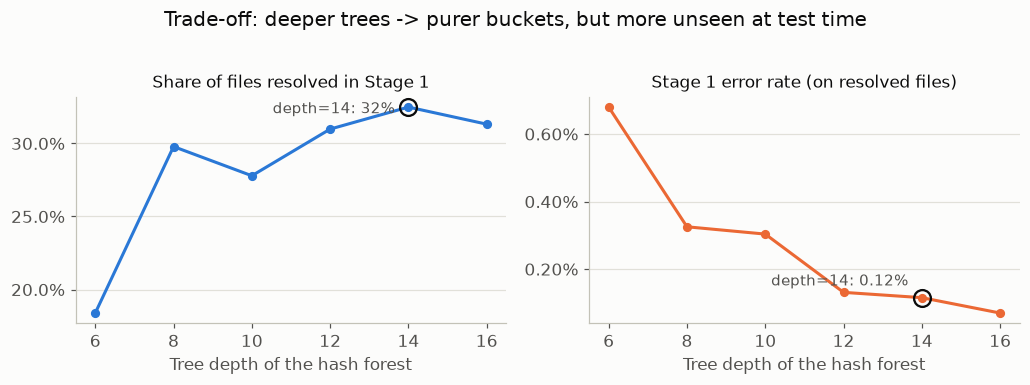

In [8]:
rows = []
forests = {}
for depth in [6, 8, 10, 12, 14, 16]:
    forests[depth] = train_hash_forest(depth)
    tab = build_bucket_table(leaf_hash(forests[depth], Xl_fit), y_fit)
    cats = stage1_lookup(leaf_hash(forests[depth], Xl_val), tab)
    resolved = np.isin(cats, ['black', 'white'])
    pred = (cats == 'black').astype(int)
    err = float((pred[resolved] != y_val[resolved]).mean()) if resolved.any() else np.nan
    rows.append(dict(depth=depth, buckets=len(tab),
                     coverage=resolved.mean(), stage1_err=err))
sweep = pd.DataFrame(rows)

# selection rule: maximize Stage 1 coverage subject to Stage 1 error <= 0.5%
ok = sweep[sweep['stage1_err'] <= 0.005]
HASH_DEPTH = int((ok if len(ok) else sweep).sort_values('coverage').iloc[-1]['depth'])
print(sweep.to_string(index=False, formatters={
    'coverage': '{:.1%}'.format, 'stage1_err': '{:.3%}'.format}))
print(f'\nselected tree depth HASH_DEPTH = {HASH_DEPTH}')

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for ax, col, color, title, fmt, off, halign in [
        (axes[0], 'coverage', PAL['blue'], 'Share of files resolved in Stage 1', '{:.0%}', (-9, -4), 'right'),
        (axes[1], 'stage1_err', PAL['orange'], 'Stage 1 error rate (on resolved files)', '{:.2%}', (-9, 8), 'right')]:
    ax.plot(sweep['depth'], sweep[col], color=color, lw=2, marker='o', ms=5)
    sel = sweep[sweep['depth'] == HASH_DEPTH]
    ax.plot(sel['depth'], sel[col], 'o', ms=11, mfc='none', mec=PAL['ink'], mew=1.5)
    ax.annotate(f"depth={HASH_DEPTH}: {fmt.format(float(sel[col].iloc[0]))}",
                (float(sel['depth'].iloc[0]), float(sel[col].iloc[0])),
                textcoords='offset points', xytext=off, ha=halign,
                color=PAL['ink2'], fontsize=10)
    ax.set_xlabel('Tree depth of the hash forest')
    ax.set_title(title, fontsize=11, color=PAL['ink'])
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
    style_ax(ax)
fig.suptitle('Trade-off: deeper trees -> purer buckets, but more unseen at test time',
             y=1.02, color=PAL['ink'])
plt.tight_layout(); plt.show()

       buckets  train samples
cat                          
black      467          29054
white      323          14003
hard     67671          84943


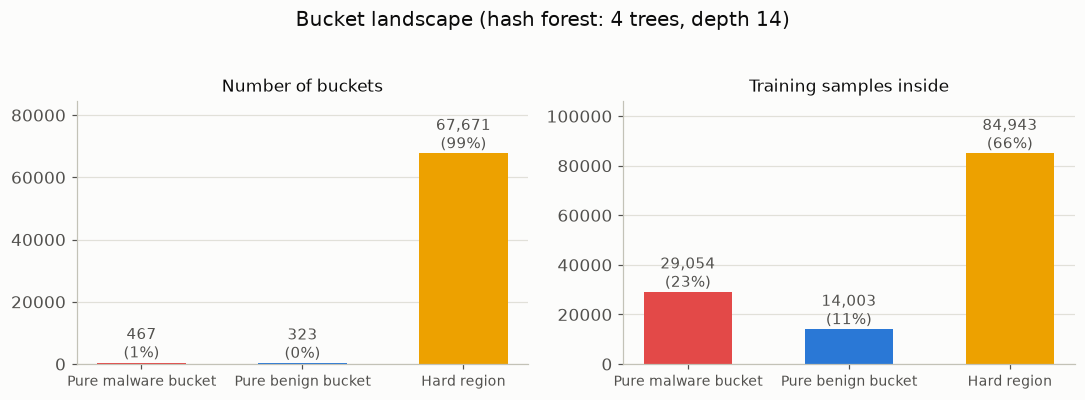

In [9]:
# build the final bucket table on the fit set with the selected depth
hash_forest = forests[HASH_DEPTH]
bid_fit = leaf_hash(hash_forest, Xl_fit)
bucket_table = build_bucket_table(bid_fit, y_fit)
cat_of_fit = stage1_lookup(bid_fit, bucket_table)

bstat = bucket_table.groupby('cat')['n'].agg(['count', 'sum']).reindex(['black', 'white', 'hard'])
bstat.columns = ['buckets', 'train samples']
print(bstat.to_string())

CAT_COLORS = {'black': PAL['mal'], 'white': PAL['ben'], 'hard': PAL['hard'], 'unseen': PAL['unseen']}
CAT_LABELS = {'black': 'Pure malware bucket', 'white': 'Pure benign bucket',
              'hard': 'Hard region', 'unseen': 'Unseen bucket'}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
cats3 = ['black', 'white', 'hard']
counts = [int(bucket_table[bucket_table['cat'] == c].shape[0]) for c in cats3]
samples = [int(bucket_table.loc[bucket_table['cat'] == c, 'n'].sum()) for c in cats3]
for ax, vals, title in [(axes[0], counts, 'Number of buckets'),
                        (axes[1], samples, 'Training samples inside')]:
    bars = ax.bar([CAT_LABELS[c] for c in cats3], vals,
                  color=[CAT_COLORS[c] for c in cats3], width=0.55)
    total = sum(vals)
    for b, v in zip(bars, vals):
        ax.annotate(f'{v:,}\n({v/total:.0%})', (b.get_x() + b.get_width()/2, v),
                    ha='center', va='bottom', fontsize=10, color=PAL['ink2'])
    ax.set_title(title, fontsize=11, color=PAL['ink'])
    ax.set_ylim(0, max(vals) * 1.25)
    ax.tick_params(axis='x', labelsize=9)
    style_ax(ax)
fig.suptitle(f'Bucket landscape (hash forest: {N_TREES} trees, depth {HASH_DEPTH})',
             y=1.03, color=PAL['ink'])
plt.tight_layout(); plt.show()

## 4. Stage 2: gradient-boosted trees for the hard regions

Only files that reach Stage 2 get their **heavy features** (1248 dims) extracted and
scored by **XGBoost** (standing in for the whitepaper's decision-tree ensemble).

The crucial training-set construction follows the paper's anti-false-positive design
to the letter:

> "*classifiers in each hard region are trained on malware from only one bucket — but on
> **all clean objects available in all the buckets** of the training set.*"

That is: **malware samples come only from hard regions** (pure-malware-bucket samples
are already handled by Stage 1, so Stage 2 need not learn them), while **all benign
samples are kept**, so the model has seen as much of the "normal world" as possible —
keeping false positives down.

(The paper trains a separate model per hard region; with our data volume we train
**one** global Stage 2 model, with the same training-set construction principle.)

The decision threshold is chosen on the **validation set** for a target false-positive
rate: the 99.5th percentile of benign scores, i.e. target FPR ≈ 0.5%. (Production
systems target 1e-4 ~ 1e-5, which requires millions of benign samples to calibrate.)

In [11]:
Xh_fit, Xh_val = Xh_train[fit_idx], Xh_train[val_idx]

# whitepaper-style training set: hard-region malware + ALL benign samples
hard_mal = (y_fit == 1) & np.isin(cat_of_fit, ['hard'])
stage2_train_mask = (y_fit == 0) | hard_mal
print(f'Stage 2 training set: {stage2_train_mask.sum():,} samples '
      f'({int(hard_mal.sum()):,} malware, all from hard regions; '
      f'{int((y_fit == 0).sum()):,} benign, all kept)')

t0 = time.time()
clf = xgb.XGBClassifier(
    n_estimators=600, max_depth=8, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.8, tree_method='hist', device=XGB_DEVICE,
    n_jobs=16, eval_metric='auc', early_stopping_rounds=50, random_state=SEED)
clf.fit(Xh_fit[stage2_train_mask], y_fit[stage2_train_mask],
        eval_set=[(Xh_val, y_val)], verbose=False)
val_scores = clf.predict_proba(Xh_val)[:, 1]
THRESH = float(np.quantile(val_scores[y_val == 0], 0.995))
print(f'training took {time.time()-t0:.0f}s | best iteration {clf.best_iteration} | '
      f'validation AUC = {roc_auc_score(y_val, val_scores):.4f}')
print(f'decision threshold THRESH = {THRESH:.4f} '
      f'(99.5th percentile of benign validation scores, target FPR 0.5%)')

Stage 2 training set: 98,946 samples (35,040 malware, all from hard regions; 63,906 benign, all kept)


training took 22s | best iteration 599 | validation AUC = 0.9956
decision threshold THRESH = 0.9196 (99.5th percentile of benign validation scores, target FPR 0.5%)


## 5. End-to-end evaluation: the two-stage funnel

Now we run the full pipeline on the **test set** (20,000 files that first appeared in
Nov-Dec 2018 — never seen during training):

```
file --lightweight features--> similarity hash (leaf paths) --bucket lookup--+-- pure malware bucket --> flag malware (scan ends)
                                                                             +-- pure benign bucket  --> release      (scan ends)
                                                                             +-- hard / unseen --heavy features--> XGBoost --> verdict
```

Stage 1 processed 20,000 files in 29ms; Stage 2 only ran on 15,273 files (76.4%), taking 241ms


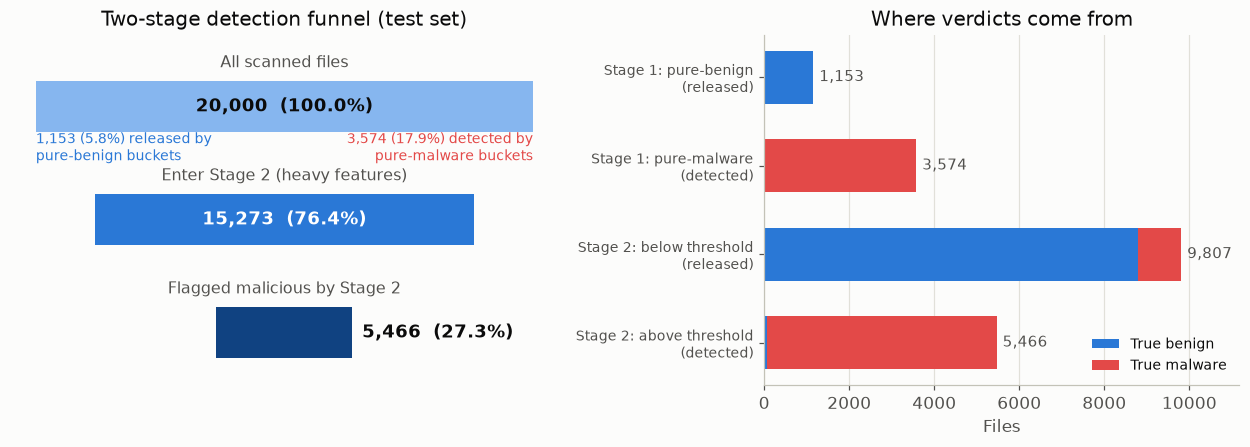

error sources: Stage 1 FP 1 / FN 2 | Stage 2 FP 65 / FN 1024


In [12]:
# ---- the full two-stage pipeline ----
t0 = time.time()
cats_test = stage1_lookup(leaf_hash(hash_forest, Xl_test), bucket_table)
t_stage1 = time.time() - t0

to_stage2 = np.isin(cats_test, ['hard', 'unseen'])
pred = np.zeros(len(y_test), dtype=int)
pred[cats_test == 'black'] = 1

t0 = time.time()
s2_scores = clf.predict_proba(Xh_test[to_stage2])[:, 1]
pred[to_stage2] = (s2_scores >= THRESH).astype(int)
t_stage2 = time.time() - t0

n_total = len(y_test)
n_white = int((cats_test == 'white').sum())
n_black = int((cats_test == 'black').sum())
n_s2 = int(to_stage2.sum())
n_s2_mal = int(pred[to_stage2].sum())
print(f'Stage 1 processed {n_total:,} files in {t_stage1*1000:.0f}ms; '
      f'Stage 2 only ran on {n_s2:,} files ({n_s2/n_total:.1%}), taking {t_stage2*1000:.0f}ms')

# ---- funnel + verdict breakdown ----
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2), width_ratios=[1.15, 1])

levels = [('All scanned files', n_total),
          ('Enter Stage 2 (heavy features)', n_s2),
          ('Flagged malicious by Stage 2', n_s2_mal)]
ys = [0.0, -1.5, -3.0]
for yy, (name, v), color in zip(ys, levels, PAL['funnel']):
    ax.barh(yy, v, left=-v/2, height=0.68, color=color)
    ax.annotate(name, (0, yy + 0.52), ha='center', fontsize=10.5, color=PAL['ink2'])
    label = f'{v:,}  ({v/n_total:.1%})'
    if v > n_total * 0.45:      # bar wide enough -> label inside
        ax.annotate(label, (0, yy), ha='center', va='center', fontsize=11.5,
                    fontweight='bold', color=PAL['ink'] if yy == 0 else 'white')
    else:                       # narrow bar -> label to the right
        ax.annotate(label, (v/2 + n_total*0.02, yy), ha='left', va='center',
                    fontsize=11.5, fontweight='bold', color=PAL['ink'])
gap_y = (ys[0] + ys[1]) / 2 + 0.2
ax.annotate(f'{n_white:,} ({n_white/n_total:.1%}) released by\npure-benign buckets',
            (-n_total/2, gap_y), ha='left', va='center', fontsize=9, color=PAL['ben'])
ax.annotate(f'{n_black:,} ({n_black/n_total:.1%}) detected by\npure-malware buckets',
            (n_total/2, gap_y), ha='right', va='center', fontsize=9, color=PAL['mal'])
ax.set_xlim(-n_total/2 * 1.1, n_total/2 * 1.1)
ax.set_ylim(-3.7, 0.95)
ax.axis('off')
ax.set_title('Two-stage detection funnel (test set)', color=PAL['ink'])

# verdict sources: how many true malware / benign inside each exit
sources = [('Stage 1: pure-benign\n(released)', cats_test == 'white'),
           ('Stage 1: pure-malware\n(detected)', cats_test == 'black'),
           ('Stage 2: below threshold\n(released)', to_stage2 & (pred == 0)),
           ('Stage 2: above threshold\n(detected)', to_stage2 & (pred == 1))]
ys = np.arange(len(sources))[::-1]
ben_c = [int(((y_test == 0) & m).sum()) for _, m in sources]
mal_c = [int(((y_test == 1) & m).sum()) for _, m in sources]
ax2.barh(ys, ben_c, height=0.6, color=PAL['ben'], label='True benign')
ax2.barh(ys, mal_c, left=ben_c, height=0.6, color=PAL['mal'], label='True malware')
for yy, (b, m) in zip(ys, zip(ben_c, mal_c)):
    ax2.annotate(f'{b+m:,}', (b + m, yy), xytext=(4, 0), textcoords='offset points',
                 va='center', fontsize=9.5, color=PAL['ink2'])
ax2.set_xlim(0, max(b + m for b, m in zip(ben_c, mal_c)) * 1.14)
ax2.set_yticks(ys, [s for s, _ in sources], fontsize=9)
ax2.set_xlabel('Files')
ax2.legend(frameon=False, loc='lower right', fontsize=9)
ax2.set_title('Where verdicts come from', color=PAL['ink'])
style_ax(ax2, ygrid=False, xgrid=True)
plt.tight_layout(); plt.show()

# error breakdown
s1_fp = int(((cats_test == 'black') & (y_test == 0)).sum())
s1_fn = int(((cats_test == 'white') & (y_test == 1)).sum())
s2_fp = int((to_stage2 & (pred == 1) & (y_test == 0)).sum())
s2_fn = int((to_stage2 & (pred == 0) & (y_test == 1)).sum())
print(f'error sources: Stage 1 FP {s1_fp} / FN {s1_fn} | Stage 2 FP {s2_fp} / FN {s2_fn}')

In [13]:
# ---- overall pipeline metrics ----
tp = int(((pred == 1) & (y_test == 1)).sum())
fp = int(((pred == 1) & (y_test == 0)).sum())
fn = int(((pred == 0) & (y_test == 1)).sum())
result = pd.DataFrame({'Two-stage pipeline (20K test files)': {
    'Detection rate (TPR)': f"{tp / max(tp + fn, 1):.2%}",
    'False positive rate (FPR)': f"{fp / max(int((y_test == 0).sum()), 1):.3%}",
    'Accuracy': f"{float((pred == y_test).mean()):.2%}",
    'False positives': fp, 'False negatives': fn,
    'Resolved directly in Stage 1': f"{1 - n_s2 / n_total:.1%}",
    'Files needing heavy features': f"{n_s2 / n_total:.1%}",
}}).T
display(result)

print(f"Bottom line: {1 - n_s2/n_total:.1%} of files are resolved at near-zero cost in the "
      f"pre-detect stage (with only {s1_fp + s1_fn} mistakes),")
print(f"and only {n_s2/n_total:.1%} of files need heavy feature extraction and the full model —")
print(f"exactly the value of the whitepaper's two-stage design: cheap Stage 1 carries the "
      f"scanning throughput, expensive deep analysis is spent only on genuinely hard files.")

,Detection rate (TPR),False positive rate (FPR),Accuracy,False positives,False negatives,Resolved directly in Stage 1,Files needing heavy features
Two-stage pipeline (20K test files),89.74%,0.660%,94.54%,66,1026,23.6%,76.4%


Bottom line: 23.6% of files are resolved at near-zero cost in the pre-detect stage (with only 3 mistakes),
and only 76.4% of files need heavy feature extraction and the full model —
exactly the value of the whitepaper's two-stage design: cheap Stage 1 carries the scanning throughput, expensive deep analysis is spent only on genuinely hard files.


## 6. Error case analysis: why FPs and FNs happen

Metrics only answer "how much did we get wrong" — a presentation needs "**why**".
This section analyzes the errors at three levels:

1. **Score distribution + threshold**: FPs and FNs are not bugs — they are the two
   costs of drawing one cut on the same score axis. Move the threshold left and you
   catch more malware (FN↓ FP↑); move it right and you wrongly flag fewer clean files
   (FP↓ FN↑). The whitepaper commits to a very low FPR — better to miss than to
   quarantine a user's legitimate files;
2. **Per-sample attribution**: XGBoost's `pred_contribs` (the tree-model version of
   SHAP values) decomposes a single prediction into exact per-feature contributions —
   positive pushes toward "malware", negative toward "benign". For hashed feature
   columns we can even **reverse-map** which concrete token of this sample (an import,
   a section name, a PE header field, ...) landed in that column;
3. **Macro causes of FNs**: which families do the missed samples come from, and did
   training ever see them? — this connects to the whitepaper's "detection rate
   degradation over time" (data distribution drift).

Case selection is deterministic (no cherry-picking):
- **FP case**: the truly benign file with the **highest** Stage 2 score — the model's
  most confident wrongful conviction;
- **FN case**: the truly malicious file with the **lowest** score — the one that fooled
  the model most completely.

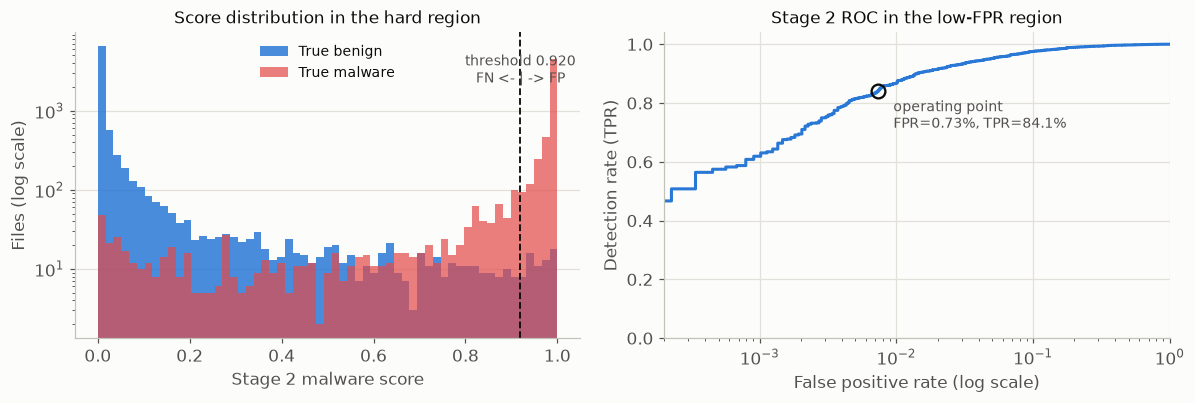

Stage 2 missed 1,024 malware files; 659 of them (64%) scored > 0.5 — near misses
Lowering the threshold to 0.5 would catch those, but false positives would rise from 65 to 342 — the trade-off behind the whitepaper's strict low-FPR stance


In [14]:
from sklearn.metrics import roc_curve

score_full = np.full(len(y_test), np.nan)
score_full[to_stage2] = s2_scores
s2_y = y_test[to_stage2]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.linspace(0, 1, 60)
ax.hist(s2_scores[s2_y == 0], bins=bins, color=PAL['ben'], alpha=0.85, label='True benign')
ax.hist(s2_scores[s2_y == 1], bins=bins, color=PAL['mal'], alpha=0.7, label='True malware')
ax.set_yscale('log')
ax.axvline(THRESH, color=PAL['ink'], ls='--', lw=1.2)
ax.annotate(f'threshold {THRESH:.3f}\nFN <- | -> FP', (THRESH, ax.get_ylim()[1] * 0.55),
            ha='center', va='top', fontsize=9, color=PAL['ink2'])
ax.set_xlabel('Stage 2 malware score')
ax.set_ylabel('Files (log scale)')
ax.set_title('Score distribution in the hard region', fontsize=11, color=PAL['ink'])
ax.legend(frameon=False, fontsize=9)
style_ax(ax)

fpr, tpr, _ = roc_curve(s2_y, s2_scores)
ax2.plot(fpr, tpr, color=PAL['blue'], lw=2)
op_fpr = ((s2_scores >= THRESH) & (s2_y == 0)).sum() / max(int((s2_y == 0).sum()), 1)
op_tpr = ((s2_scores >= THRESH) & (s2_y == 1)).sum() / max(int((s2_y == 1).sum()), 1)
ax2.plot([op_fpr], [op_tpr], 'o', ms=9, mfc='none', mec=PAL['ink'], mew=1.5)
ax2.annotate(f'operating point\nFPR={op_fpr:.2%}, TPR={op_tpr:.1%}', (op_fpr, op_tpr),
             textcoords='offset points', xytext=(10, -24), fontsize=9, color=PAL['ink2'])
ax2.set_xscale('log'); ax2.set_xlim(2e-4, 1); ax2.set_ylim(0, 1.04)
ax2.set_xlabel('False positive rate (log scale)')
ax2.set_ylabel('Detection rate (TPR)')
ax2.set_title('Stage 2 ROC in the low-FPR region', fontsize=11, color=PAL['ink'])
style_ax(ax2, ygrid=True, xgrid=True)
plt.tight_layout(); plt.show()

fn_scores = score_full[(y_test == 1) & (pred == 0) & to_stage2]
n_fp_now = int(((s2_scores >= THRESH) & (s2_y == 0)).sum())
n_fp_05  = int(((s2_scores >= 0.5) & (s2_y == 0)).sum())
print(f'Stage 2 missed {len(fn_scores):,} malware files; {int((fn_scores > 0.5).sum()):,} '
      f'of them ({(fn_scores > 0.5).mean():.0%}) scored > 0.5 — near misses')
print(f'Lowering the threshold to 0.5 would catch those, but false positives would rise '
      f'from {n_fp_now} to {n_fp_05} — the trade-off behind the whitepaper\'s strict low-FPR stance')

== FP case: the most confidently misjudged benign file ==
  sha256    : ad9ca1c312adda71689d0b1acdeea565dc4322d4455b4e28bc8b501ea3565cf0
  first seen: 2018-12   avclass: (no family label)
  Stage 2 score: 0.9997   (decision threshold 0.920)
  key features: log_size=14.23, strings_entropy=6.34, has_signature=0.00, log_imports=2.40, n_sections=5.00, n_exec_sections=3.00


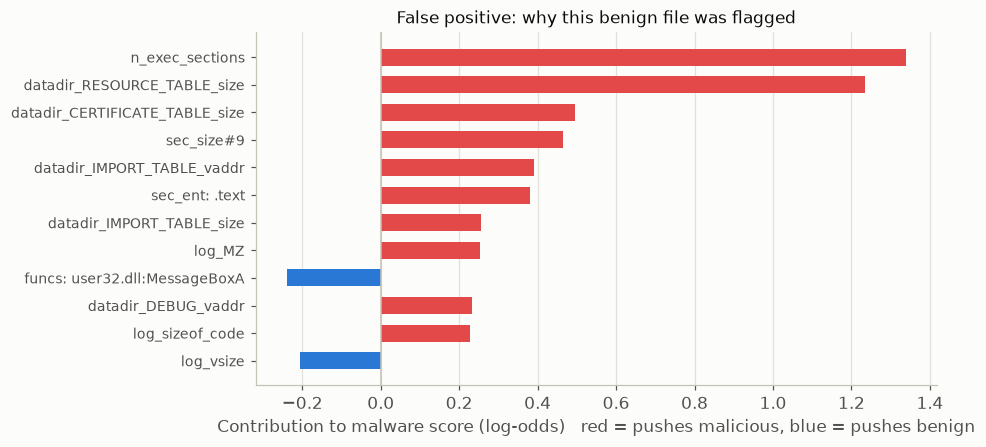

In [15]:
# ---- readable names for all 1248 feature columns (aligned with Xh) ----
GEN_NAMES = ['log_size','log_vsize','has_debug','log_exports','log_imports',
             'has_relocations','has_resources','has_signature','has_tls','log_symbols']
STR_NAMES = ['log_numstrings','avg_str_length','log_printables','strings_entropy',
             'log_paths','log_urls','log_registry','log_MZ']
HDR_NAMES = ['img_ver_major','img_ver_minor','linker_major','linker_minor','os_major','os_minor',
             'subsys_major','subsys_minor','log_sizeof_code','log_sizeof_headers','log_sizeof_heap_commit']
SEC_STAT_NAMES = ['n_sections','n_zero_size_sections','n_unnamed_sections',
                  'n_exec_sections','n_write_sections']
FEAT_NAMES = ([f'hist_0x{i:02x}' for i in range(256)]
              + [f'byteentropy_{i}' for i in range(256)] + GEN_NAMES
              + STR_NAMES + [f'printable_{chr(0x20 + i)!r}' for i in range(96)]
              + HDR_NAMES + SEC_STAT_NAMES
              + [f'datadir_{n}_{k}' for n in DD_NAMES for k in ('size', 'vaddr')]
              + [f'{g}#{j}' for g, n, _ in HASH_SPECS for j in range(n)])
assert len(FEAT_NAMES) == Xh_test.shape[1]

from sklearn.utils import murmurhash3_32
HASH_OFFSET, _off = {}, 522 + 150
for g, n, _ in HASH_SPECS:
    HASH_OFFSET[g] = (_off, n); _off += n

def resolve_feature(idx, col):
    """Column id -> readable name; for hashed columns, reverse-map the sample's tokens
    that landed in this column."""
    name = FEAT_NAMES[col]
    for g, (o, n) in HASH_OFFSET.items():
        if o <= col < o + n:
            keys = {(t[0] if isinstance(t, tuple) else t) for t in test['tokens'][idx][g]}
            hit = sorted(k for k in keys if abs(murmurhash3_32(k, seed=0)) % n == col - o)
            if hit:
                name = f"{g}: " + ', '.join(hit[:3]) + (' ...' if len(hit) > 3 else '')
            break
    return name

def explain_case(idx, case_label, chart_title):
    """Per-sample attribution: which features pushed this file's score up / down
    (pred_contribs = the tree-model version of SHAP)."""
    m = test['meta'].iloc[idx]
    contrib = clf.get_booster().predict(xgb.DMatrix(Xh_test[idx:idx + 1]), pred_contribs=True,
                                        iteration_range=(0, clf.best_iteration + 1))[0][:-1]
    print(f"== {case_label} ==")
    print(f"  sha256    : {m['sha256']}")
    print(f"  first seen: {m['appeared']}   avclass: {m['avclass'] or '(no family label)'}")
    print(f"  Stage 2 score: {score_full[idx]:.4f}   (decision threshold {THRESH:.3f})")
    keys = ['log_size', 'strings_entropy', 'has_signature', 'log_imports',
            'n_sections', 'n_exec_sections']
    print('  key features: ' + ', '.join(
        f'{k}={Xh_test[idx, FEAT_NAMES.index(k)]:.2f}' for k in keys))
    top = np.argsort(-np.abs(contrib))[:12][::-1]
    labels = [resolve_feature(idx, j) for j in top]
    vals = contrib[top]
    fig, ax = plt.subplots(figsize=(8.8, 4.2))
    ax.barh(np.arange(len(top)), vals, height=0.62,
            color=[PAL['mal'] if v > 0 else PAL['ben'] for v in vals])
    ax.axvline(0, color=PAL['axis'], lw=1)
    ax.set_yticks(np.arange(len(top)), labels, fontsize=9)
    ax.set_xlabel('Contribution to malware score (log-odds)   red = pushes malicious, blue = pushes benign')
    ax.set_title(chart_title, fontsize=11, color=PAL['ink'])
    style_ax(ax, ygrid=False, xgrid=True)
    plt.tight_layout(); plt.show()

# FP case: truly benign, highest Stage 2 score
fp_mask = (y_test == 0) & (pred == 1) & to_stage2
if fp_mask.any():
    fp_idx = int(np.argmax(np.where(fp_mask, score_full, -1)))
    explain_case(fp_idx, 'FP case: the most confidently misjudged benign file',
                 'False positive: why this benign file was flagged')
else:
    print('no Stage 2 false positives in this run')

== FN case: the malware that fooled the model most completely ==
  sha256    : f2a622028a495ccdb7c3105a3b98eec244b20de7303fdcc2b6b6f31a4798d0ce
  first seen: 2018-12   avclass: tiggre
  Stage 2 score: 0.0000   (decision threshold 0.920)
  key features: log_size=11.04, strings_entropy=5.51, has_signature=0.00, log_imports=4.37, n_sections=6.00, n_exec_sections=1.00


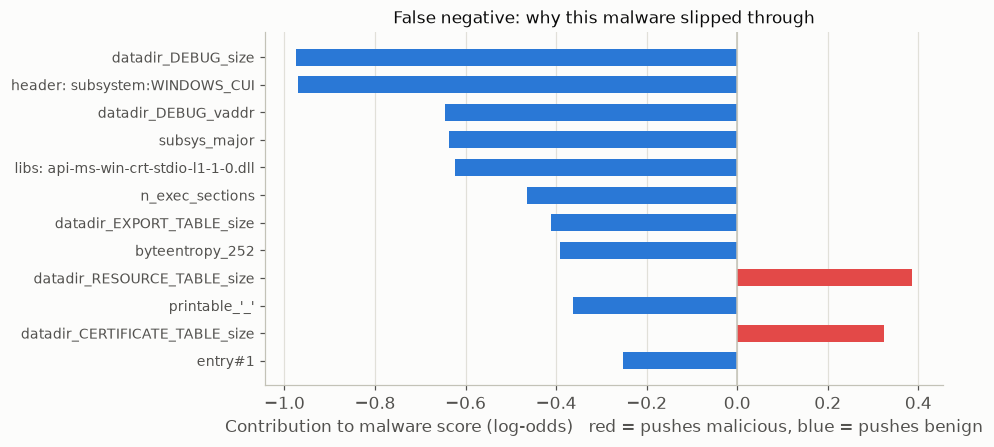

this sample's family 'tiggre' appears 501 times in the training set


In [16]:
# FN case: truly malicious, lowest Stage 2 score
fn_mask = (y_test == 1) & (pred == 0) & to_stage2
train_fams = set(train['meta'].loc[train['meta']['label'] == 1, 'avclass']) - {''}
if fn_mask.any():
    fn_idx = int(np.argmin(np.where(fn_mask, score_full, 2)))
    explain_case(fn_idx, 'FN case: the malware that fooled the model most completely',
                 'False negative: why this malware slipped through')
    fam = test['meta'].iloc[fn_idx]['avclass']
    if fam:
        n_in_train = int((train['meta']['avclass'] == fam).sum())
        novel = '' if fam in train_fams else '  <- a family never seen in training (concept drift)'
        print(f"this sample's family '{fam}' appears {n_in_train} times in the training set{novel}")
    else:
        print('this sample has no avclass family label')
else:
    print('no Stage 2 false negatives in this run')

### Reading the cases

**Why the FP happened**: the evidence pushing this benign file toward "malware" —
3 executable sections, anomalous resource-table / certificate-table sizes (**no digital
signature**), elevated `.text` section entropy. It simply **looks like a packed,
unsigned program**. This is exactly the risk the whitepaper flags with "*hard regions
... contain too many popular benign files*": installers and packer-built legitimate
software share their statistical appearance with malware, so purely static features
hit a natural ceiling on such files (production systems route these high-risk regions
to other detection technologies instead of forcing a verdict).

**Why the FN happened**: this `tiggre` (coin-miner family) sample fooled the model with
nothing but "good-citizen" traits — a DEBUG directory, console subsystem `WINDOWS_CUI`,
imports of the standard MSVC runtime `api-ms-win-crt-*`, an export table. Miners are
often compiled straight from open-source miner code: **essentially "normal software put
to bad use"**, statically almost indistinguishable from legitimate tools. Its family
appearing 501 times in training didn't help — this new variant sits on the
"benign-looking" side of the family's distribution (within-family drift).

**The macro picture for FNs** (chart below): the top-10 missed families were **all seen
in training**; genuinely novel families account for only about 3%. The dominant causes
of misses are ① **new variants of known families** (within-family distribution drift)
and ② **borderline samples** — about two thirds of the misses actually scored above
0.5, just below the threshold raised to suppress false positives. This echoes two of
the whitepaper's arguments: distributions drift continuously → models need constant
retraining plus instant cloud-side bucket updates; FPR comes first → detection rate is
the side that is **deliberately** sacrificed.

(The numbers come from this run with fixed random seeds + sampling caches; resampling
would change them slightly, but the pattern is stable.)

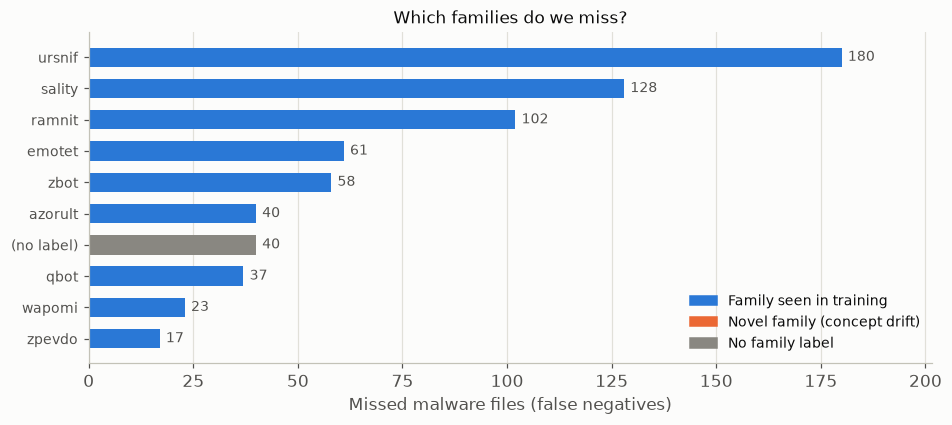

1,026 malware files missed in total; among the family-labeled misses, 3% come from families never seen in training
Two causes: (1) new families / new variants (distribution drift -> continuous retraining and cloud-side updates);
            (2) borderline samples scoring just below the threshold (the detection-rate price of a strict low-FPR policy)


In [17]:
# ---- macro causes of FNs: concept drift ----
fn_all = (y_test == 1) & (pred == 0)
fam_fn = test['meta'].loc[fn_all, 'avclass'].replace('', '(no label)')
top_fn = fam_fn.value_counts().head(10)

def fam_color(f):
    if f == '(no label)': return PAL['unseen']
    return PAL['blue'] if f in train_fams else PAL['orange']

fig, ax = plt.subplots(figsize=(8.8, 4))
ypos = np.arange(len(top_fn))[::-1]
ax.barh(ypos, top_fn.to_numpy(), height=0.62, color=[fam_color(f) for f in top_fn.index])
for yy, v in zip(ypos, top_fn.to_numpy()):
    ax.annotate(f'{v:,}', (v, yy), xytext=(4, 0), textcoords='offset points',
                va='center', fontsize=9, color=PAL['ink2'])
ax.set_yticks(ypos, top_fn.index, fontsize=9)
ax.set_xlim(0, top_fn.max() * 1.12)
handles = [mpl.patches.Patch(color=PAL['blue'], label='Family seen in training'),
           mpl.patches.Patch(color=PAL['orange'], label='Novel family (concept drift)'),
           mpl.patches.Patch(color=PAL['unseen'], label='No family label')]
ax.legend(handles=handles, frameon=False, fontsize=9, loc='lower right')
ax.set_xlabel('Missed malware files (false negatives)')
ax.set_title('Which families do we miss?', fontsize=11, color=PAL['ink'])
style_ax(ax, ygrid=False, xgrid=True)
plt.tight_layout(); plt.show()

labeled = fam_fn[fam_fn != '(no label)']
novel_share = np.mean([f not in train_fams for f in labeled]) if len(labeled) else 0
print(f'{int(fn_all.sum()):,} malware files missed in total; among the family-labeled misses, '
      f'{novel_share:.0%} come from families never seen in training')
print('Two causes: (1) new families / new variants (distribution drift -> continuous '
      'retraining and cloud-side updates);')
print('            (2) borderline samples scoring just below the threshold '
      '(the detection-rate price of a strict low-FPR policy)')

## 7. Summary

This demo reproduces the full loop of the whitepaper's two-stage pre-execution
detection:

1. **Stage 1 (pre-detect)**: supervised leaf-path hash buckets resolve a substantial
   share of files at near-zero cost (pure malware buckets detect, pure benign buckets
   release);
2. **Stage 2 (detect)**: only hard-region files get heavy features and go through
   XGBoost, trained on "hard-region malware + all benign" to keep false positives down;
3. **The funnel effect**: about a quarter of the files are resolved in the pre-detect
   stage at near-zero cost and near-zero error; expensive heavy-feature extraction is
   spent only on genuinely hard files;
4. **Error attribution**: FPs come from unsigned benign software that "looks packed";
   FNs are mostly new variants of known families plus borderline samples held back by
   the low-FPR threshold.

### Differences from the production system (also ideas to explore next)

| Dimension | Whitepaper production system | This demo |
|---|---|---|
| Similarity hashing | Supervised similarity hashing trained on **pairs** of similar/dissimilar objects | Supervised leaf-path hashing (random forest, trained on class labels) |
| Stage 2 models | One dedicated model per hard region | One global model |
| Data scale | Tens of millions of samples, FPR target 1e-4 ~ 1e-5 | 180K samples, FPR target 0.5% |
| Features | Extracted in-house (incl. disassembly) | Light/heavy subsets of EMBER's pre-extracted features |
| Updates | Hash-bucket database can be pushed from the cloud in seconds (new malware buckets take effect instantly, no retraining) | Static experiment |

> That last row is the hidden superpower of the two-stage architecture: when a new
> malware family is discovered, adding its similarity hash to the "pure malware bucket"
> database protects users immediately — this is what the whitepaper means by
> *models can be updated 'on the fly' between retraining*.